In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual para gráficos mais elegantes no portfólio
sns.set_theme(style="whitegrid", palette="muted")

# 1. Carregando os dados
#df = pd.read_csv(r'H:\Universidade dos dados\projetos\car_price\car_price_prediction_.csv')
               
df = pd.read_csv(r'C:\Users\gustavos\Documents\projetos\car_price\car_price_prediction_.csv')



1. ESTATÍSTICAS DESCRITIVAS DO PREÇO
mean      52638.02
median    53485.24
std       27295.83
min        5011.27
max       99982.59
Name: Price, dtype: float64

2. VISUALIZAÇÃO DA DISTRIBUIÇÃO DOS PREÇOS


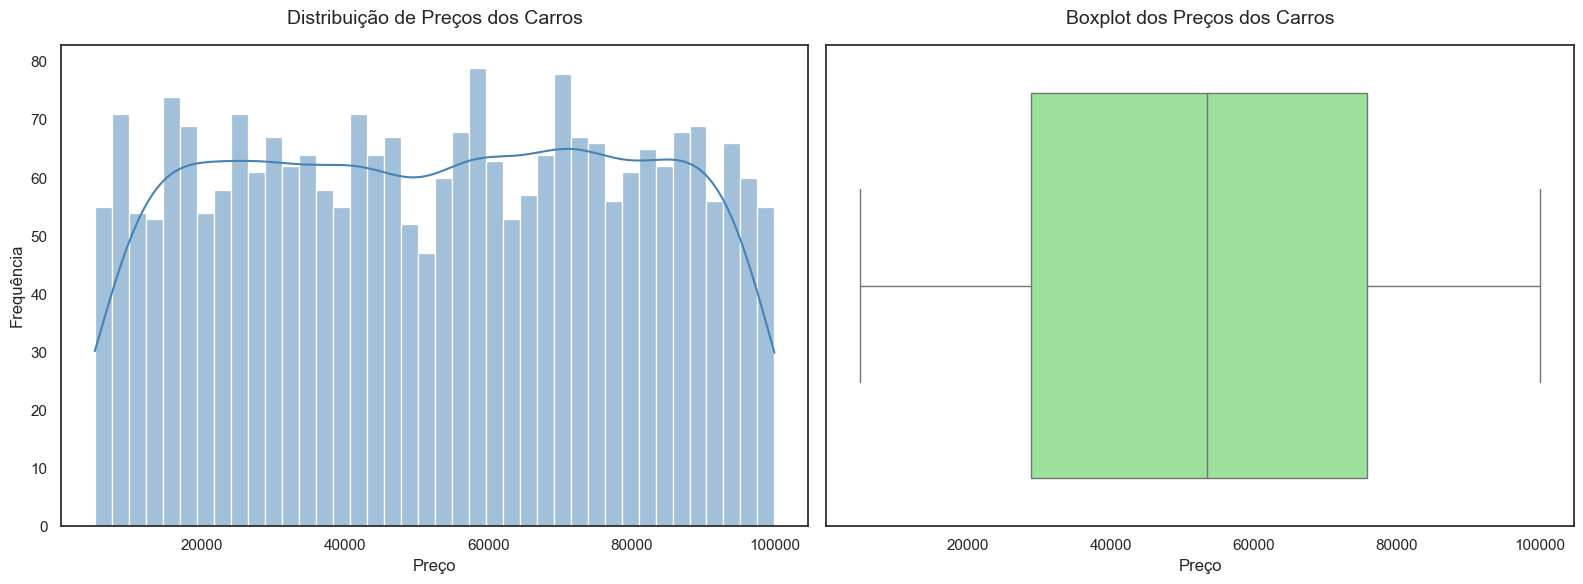

In [6]:
print("="*60)
print("1. ESTATÍSTICAS DESCRITIVAS DO PREÇO")
print("="*60)
# Calculando média, mediana, desvio padrão, mínimo e máximo
estatisticas_preco = df['Price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
print(estatisticas_preco)


print("\n" + "="*60)
print("2. VISUALIZAÇÃO DA DISTRIBUIÇÃO DOS PREÇOS")
print("="*60)
# Criando uma figura com dois subplots (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma com curva de densidade (KDE)
sns.histplot(df['Price'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição de Preços dos Carros', fontsize=14, pad=15)
axes[0].set_xlabel('Preço', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)

# Boxplot
sns.boxplot(x=df['Price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot dos Preços dos Carros', fontsize=14, pad=15)
axes[1].set_xlabel('Preço', fontsize=12)

plt.tight_layout()
plt.show()


3. PROPORÇÃO POR COMBUSTÍVEL E CONDIÇÃO
--- Proporção por Tipo de Combustível (%) ---
Fuel Type
Diesel      26.20
Petrol      25.20
Electric    24.56
Hybrid      24.04
Name: proportion, dtype: float64

--- Proporção por Condição do Veículo (%) ---
Condition
Used        34.20
Like New    33.44
New         32.36
Name: proportion, dtype: float64

4. ANÁLISE DE MARCAS
O conjunto de dados possui um total de 7 marcas únicas.

As 5 marcas mais comuns presentes nos dados são:
Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Name: count, dtype: int64

5. RELAÇÃO ANO VS PREÇO E TAMANHO DO MOTOR


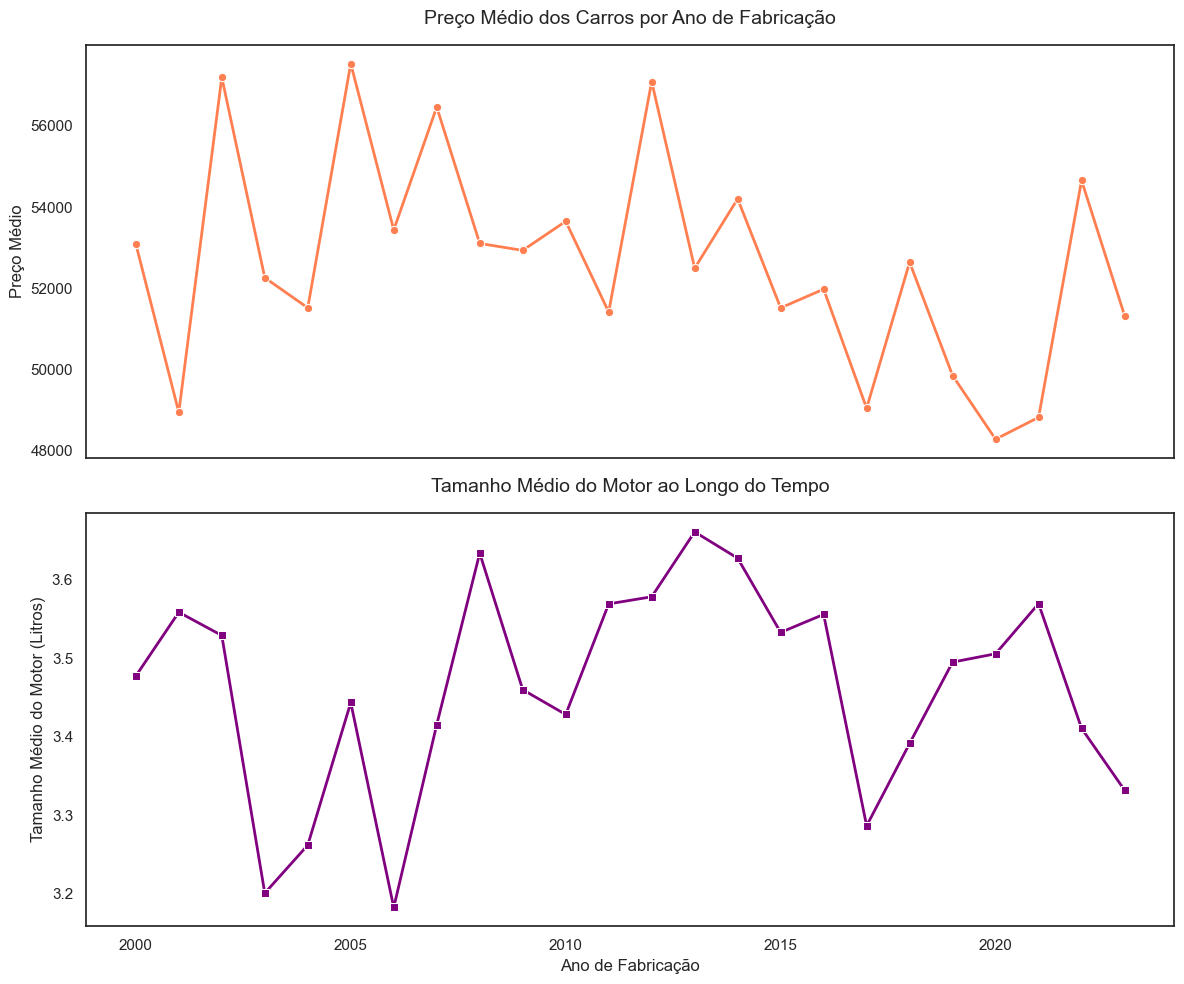

In [7]:
print("\n" + "="*60)
print("3. PROPORÇÃO POR COMBUSTÍVEL E CONDIÇÃO")
print("="*60)
# normalize=True retorna a frequência relativa; multiplicamos por 100 para ter a porcentagem
prop_combustivel = (df['Fuel Type'].value_counts(normalize=True) * 100).round(2)
prop_condicao = (df['Condition'].value_counts(normalize=True) * 100).round(2)

print("--- Proporção por Tipo de Combustível (%) ---")
print(prop_combustivel)
print("\n--- Proporção por Condição do Veículo (%) ---")
print(prop_condicao)


print("\n" + "="*60)
print("4. ANÁLISE DE MARCAS")
print("="*60)
num_marcas = df['Brand'].nunique()
top_5_marcas = df['Brand'].value_counts().head(5)

print(f"O conjunto de dados possui um total de {num_marcas} marcas únicas.")
print("\nAs 5 marcas mais comuns presentes nos dados são:")
print(top_5_marcas)


print("\n" + "="*60)
print("5. RELAÇÃO ANO VS PREÇO E TAMANHO DO MOTOR")
print("="*60)
# Agrupando os dados pelo ano de fabricação e calculando a média das variáveis
tendencias_ano = df.groupby('Year').agg(
    Preco_Medio=('Price', 'mean'),
    Motor_Medio=('Engine Size', 'mean')
).reset_index()

# Visualização das tendências históricas
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Gráfico de linha para Preço Médio
sns.lineplot(data=tendencias_ano, x='Year', y='Preco_Medio', marker='o', ax=axes[0], color='coral', linewidth=2)
axes[0].set_title('Preço Médio dos Carros por Ano de Fabricação', fontsize=14, pad=15)
axes[0].set_ylabel('Preço Médio', fontsize=12)

# Gráfico de linha para Tamanho Médio do Motor
sns.lineplot(data=tendencias_ano, x='Year', y='Motor_Medio', marker='s', ax=axes[1], color='purple', linewidth=2)
axes[1].set_title('Tamanho Médio do Motor ao Longo do Tempo', fontsize=14, pad=15)
axes[1].set_ylabel('Tamanho Médio do Motor (Litros)', fontsize=12)
axes[1].set_xlabel('Ano de Fabricação', fontsize=12)

plt.tight_layout()
plt.show()


4. ANÁLISE DE MARCAS: QUANTIDADE E LIDERANÇA DE MERCADO
O dataset contempla 7 marcas distintas.

--- Tabela: Top 5 Marcas no Dataset ---
   Marca  Quantidade  Participação (%)
  Toyota         374             14.96
    Audi         368             14.72
     BMW         358             14.32
Mercedes         353             14.12
   Honda         352             14.08
----------------------------------------


C:\Users\gustavos\AppData\Local\Temp\ipykernel_11916\3987962718.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


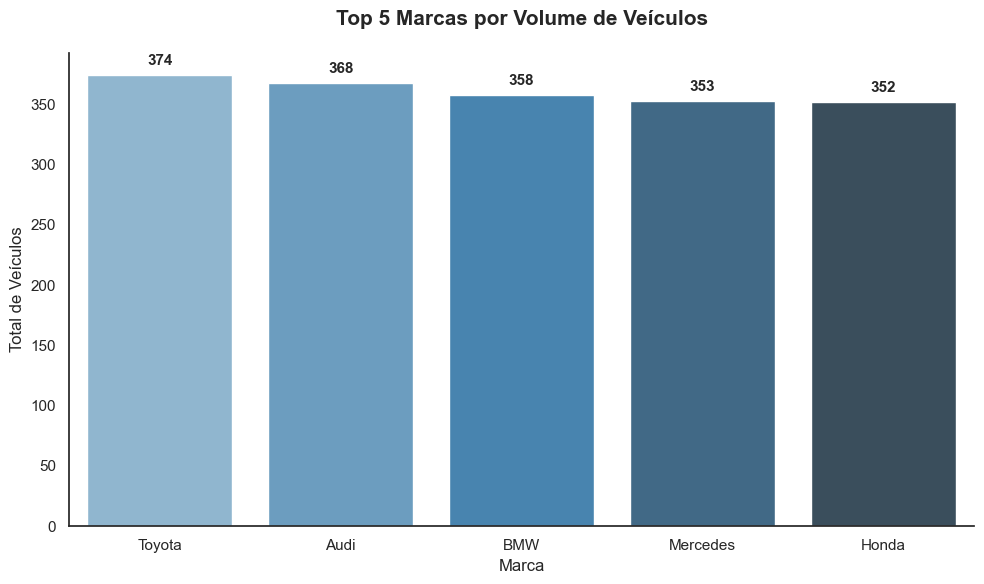

In [9]:
# Configuração de estilo
sns.set_theme(style="white")

# ... (assumindo que o df já foi carregado) ...

print("\n" + "="*60)
print("4. ANÁLISE DE MARCAS: QUANTIDADE E LIDERANÇA DE MERCADO")
print("="*60)

# 1. Cálculo da quantidade total de marcas
num_marcas = df['Brand'].nunique()
print(f"O dataset contempla {num_marcas} marcas distintas.\n")

# 2. Criação da Tabela com as 5 marcas mais comuns
# Calculamos a contagem e a porcentagem para tornar a tabela mais profissional
top_5_marcas = df['Brand'].value_counts().head(5).reset_index()
top_5_marcas.columns = ['Marca', 'Quantidade']
top_5_marcas['Participação (%)'] = (top_5_marcas['Quantidade'] / len(df) * 100).round(2)

print("--- Tabela: Top 5 Marcas no Dataset ---")
print(top_5_marcas.to_string(index=False))
print("-" * 40)

# 3. Visualização Gráfica
plt.figure(figsize=(10, 6))

# Criando o gráfico de barras
ax = sns.barplot(
    data=top_5_marcas, 
    x='Marca', 
    y='Quantidade', 
    palette='Blues_d'
)

# Estilização do gráfico
plt.title('Top 5 Marcas por Volume de Veículos', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Marca', fontsize=12)
plt.ylabel('Total de Veículos', fontsize=12)

# Adicionando os rótulos de valor sobre as barras para precisão
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

sns.despine() # Remove as bordas desnecessárias
plt.tight_layout()
plt.show()

6. ANÁLISE RIGOROSA: PREÇO MÉDIO POR CONDIÇÃO
  Condition     Price
0  Like New  53518.75
1      Used  52470.92
2       New  51904.51

A distância máxima entre os valores médios é de: R$ 1,614.24


C:\Users\gustavos\AppData\Local\Temp\ipykernel_11916\1828923148.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


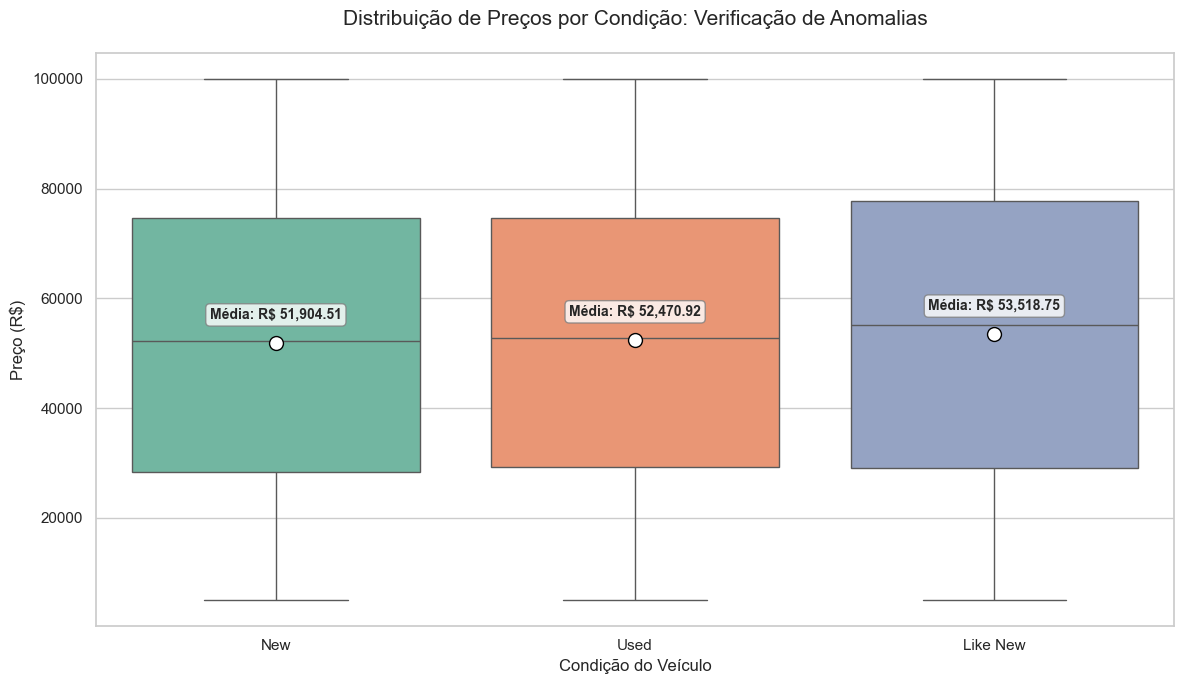

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo para portfólio
sns.set_theme(style="whitegrid")

# 1. Cálculo das Médias por Condição
# Agrupamos para entender a "distância" numérica entre as categorias
df_mean_price = df.groupby('Condition')['Price'].mean().sort_values(ascending=False).reset_index()

print("="*60)
print("6. ANÁLISE RIGOROSA: PREÇO MÉDIO POR CONDIÇÃO")
print("="*60)
print(df_mean_price.round(2))

# Cálculo da amplitude (distância entre a maior e menor média)
distancia_max = df_mean_price['Price'].max() - df_mean_price['Price'].min()
print(f"\nA distância máxima entre os valores médios é de: R$ {distancia_max:,.2f}")

# 2. Visualização: Boxplot Comparativo com Médias e Rótulos
plt.figure(figsize=(12, 7))

# Criando o boxplot
ax = sns.boxplot(
    data=df, 
    x='Condition', 
    y='Price', 
    palette='Set2',
    showmeans=True, # Adiciona o ponto da média
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"}
)

# Adicionando rótulos de valor (médias) acima de cada categoria no gráfico
for i, row in df_mean_price.iterrows():
    # Localiza a posição da categoria no eixo X
    pos = list(ax.get_xticklabels()).index(next(label for label in ax.get_xticklabels() if label.get_text() == row['Condition']))
    
    ax.annotate(
        f"Média: R$ {row['Price']:,.2f}", 
        xy=(pos, row['Price']), 
        xytext=(0, 15), 
        textcoords='offset points',
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8)
    )

plt.title('Distribuição de Preços por Condição: Verificação de Anomalias', fontsize=15, pad=20)
plt.xlabel('Condição do Veículo', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)

plt.tight_layout()
plt.show()


7. INVESTIGANDO ANOMALIAS: QUILOMETRAGEM E MARCAS POR CONDIÇÃO
--- Tabela: Quilometragem Média por Condição ---
Condição  Quilometragem Média
    Used            148586.63
     New            148667.97
Like New            151986.43
----------------------------------------


C:\Users\gustavos\AppData\Local\Temp\ipykernel_11916\1091877665.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=km_por_condicao, x='Condição', y='Quilometragem Média', palette='viridis')


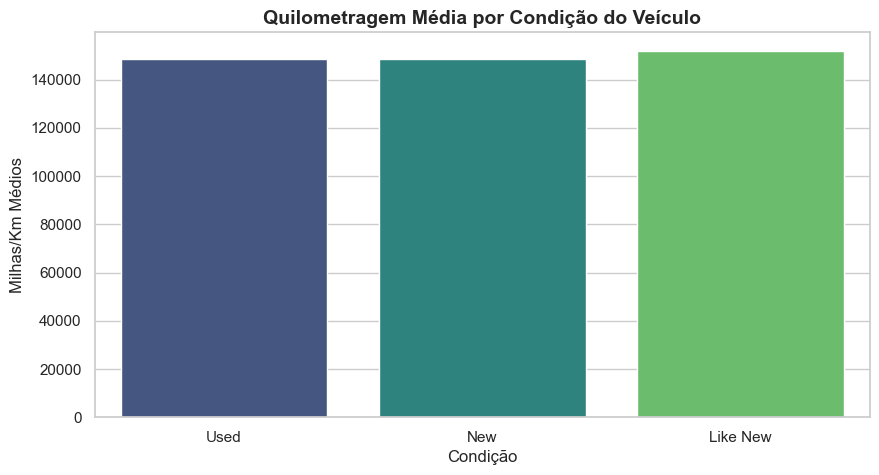


--- Top 3 Marcas por Condição ---

Condição: New
 - Audi: 129 veículos
 - Toyota: 120 veículos
 - Tesla: 119 veículos

Condição: Used
 - Toyota: 145 veículos
 - Audi: 128 veículos
 - Mercedes: 128 veículos

Condição: Like New
 - BMW: 138 veículos
 - Ford: 124 veículos
 - Honda: 123 veículos


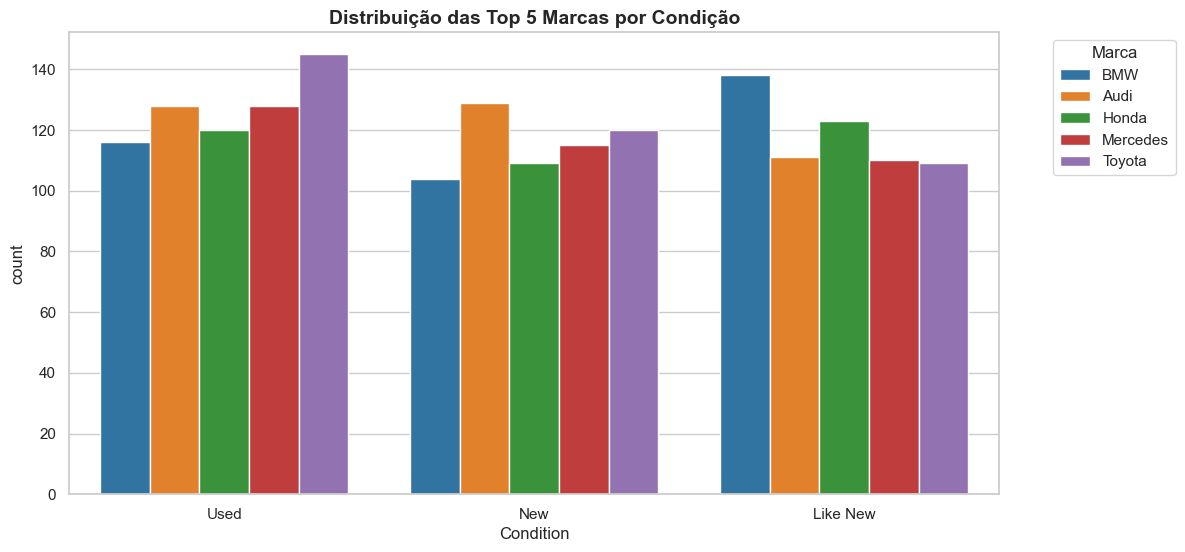

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ... (assumindo que o df já foi carregado) ...

print("\n" + "="*60)
print("7. INVESTIGANDO ANOMALIAS: QUILOMETRAGEM E MARCAS POR CONDIÇÃO")
print("="*60)

# 1. Média de Quilometragem por Condição
# Aqui verificamos se a quilometragem justifica os preços
km_por_condicao = df.groupby('Condition')['Mileage'].mean().sort_values().reset_index()
km_por_condicao.columns = ['Condição', 'Quilometragem Média']

print("--- Tabela: Quilometragem Média por Condição ---")
print(km_por_condicao.round(2).to_string(index=False))
print("-" * 40)

# Visualização da Quilometragem
plt.figure(figsize=(10, 5))
sns.barplot(data=km_por_condicao, x='Condição', y='Quilometragem Média', palette='viridis')
plt.title('Quilometragem Média por Condição do Veículo', fontsize=14, fontweight='bold')
plt.ylabel('Milhas/Km Médios')
plt.show()

# 2. Marcas mais presentes para cada Condição
# Vamos criar um ranking das Top 3 marcas para cada categoria de condição
print("\n--- Top 3 Marcas por Condição ---")
condicoes = df['Condition'].unique()

for cond in condicoes:
    top_marcas = df[df['Condition'] == cond]['Brand'].value_counts().head(3)
    print(f"\nCondição: {cond}")
    for marca, qtd in top_marcas.items():
        print(f" - {marca}: {qtd} veículos")

# Visualização Comparativa de Marcas por Condição
plt.figure(figsize=(12, 6))
# Filtramos apenas as top marcas globais para o gráfico não ficar poluído
top_marcas_globais = df['Brand'].value_counts().head(5).index
df_filtrado = df[df['Brand'].isin(top_marcas_globais)]

sns.countplot(data=df_filtrado, x='Condition', hue='Brand', palette='tab10')
plt.title('Distribuição das Top 5 Marcas por Condição', fontsize=14, fontweight='bold')
plt.legend(title='Marca', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


8. EVOLUÇÃO TEMPORAL: COMPOSIÇÃO DE CONDIÇÕES POR ANO


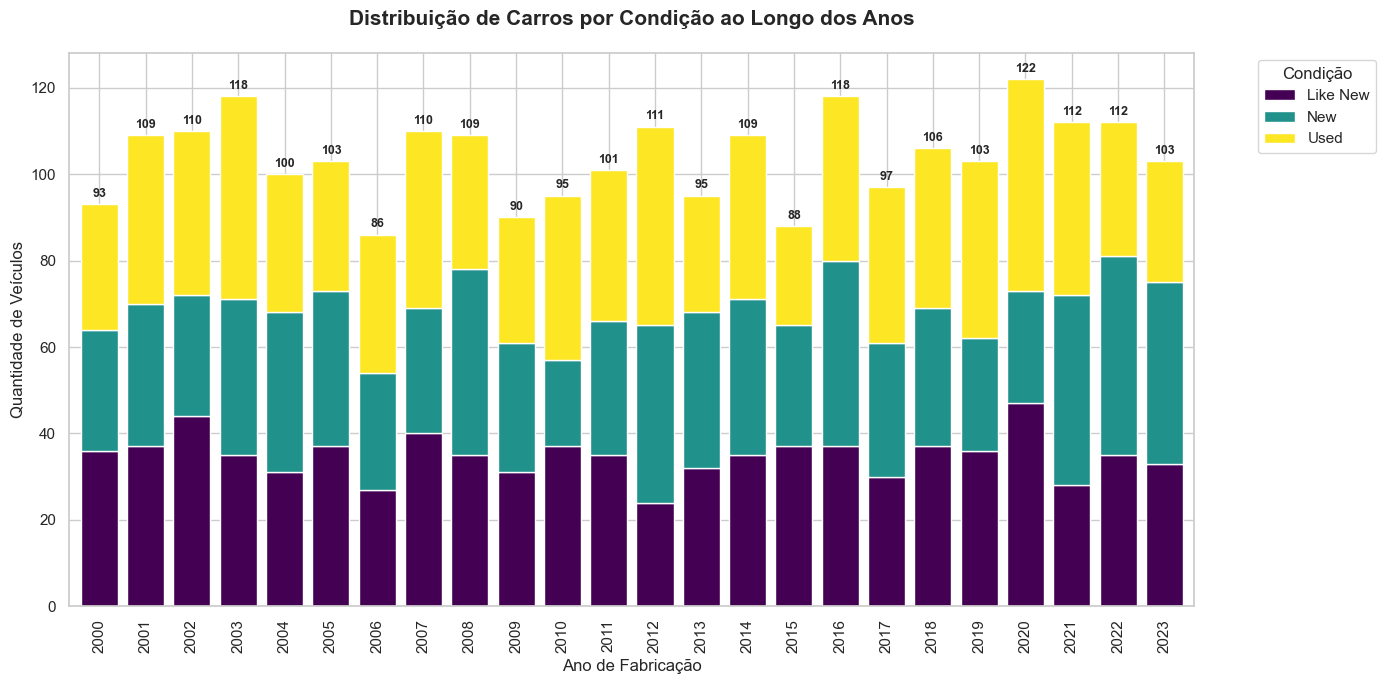

--- Amostra da Tabela de Contingência (Últimos 5 anos) ---
Condition  Like New  New  Used
Year                          
2019             36   26    41
2020             47   26    49
2021             28   44    40
2022             35   46    31
2023             33   42    28


In [14]:
# ... (assumindo que o df já foi carregado) ...

print("\n" + "="*60)
print("8. EVOLUÇÃO TEMPORAL: COMPOSIÇÃO DE CONDIÇÕES POR ANO")
print("="*60)

# 1. Preparação dos dados: Criando uma tabela de contingência (crosstab)
# Isso conta quantos carros de cada condição existem para cada ano
df_condicao_ano = pd.crosstab(df['Year'], df['Condition'])

# 2. Plotagem do Gráfico de Barras Empilhadas
# O pandas integra-se ao matplotlib para gerar barras empilhadas de forma simples
ax = df_condicao_ano.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis', width=0.8)

# 3. Estilização e Refinamento
plt.title('Distribuição de Carros por Condição ao Longo dos Anos', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Ano de Fabricação', fontsize=12)
plt.ylabel('Quantidade de Veículos', fontsize=12)
plt.legend(title='Condição', bbox_to_anchor=(1.05, 1), loc='upper left')

# Opcional: Adicionar rótulos de totais no topo das barras para rigor numérico
totals = df_condicao_ano.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + 1, str(int(total)), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Verificação de Correlação (Insight Bônus para o Portfólio)
# Vamos verificar se carros mais novos realmente têm "melhores" condições nos dados
print("--- Amostra da Tabela de Contingência (Últimos 5 anos) ---")
print(df_condicao_ano.tail(5))

In [18]:
import plotly.express as px

# ... (assumindo que o df já foi carregado) ...

print("\n" + "="*60)
print("9. TREEMAP HIERÁRQUICO: CONDIÇÃO, COMBUSTÍVEL E CÂMBIO")
print("="*60)

# 1. Preparação dos dados: Agrupando para contar as ocorrências
# Criamos um DataFrame consolidado com a contagem para cada combinação
df_treemap = df.groupby(['Condition', 'Fuel Type', 'Transmission']).size().reset_index(name='Count')

# 2. Criação do Treemap com Plotly
fig = px.treemap(
    df_treemap, 
    path=['Condition', 'Fuel Type', 'Transmission'], # Hierarquia das caixas
    values='Count',                                  # Tamanho das caixas baseado na contagem
    color='Condition',                               # Cores diferenciadas por Condição
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='Distribuição de Inventário: Condição > Combustível > Câmbio'
)

# 3. Refinamento de layout e rótulos
fig.update_traces(textinfo="label+value+percent parent")
fig.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    title_font_size=20
)

# Exibe o gráfico (em notebooks como Jupyter ou Colab ele será interativo)
fig.show()

# 4. Alternativa Estática (caso precise salvar como imagem para o portfólio)
# fig.write_image("treemap_veiculos.png")


9. TREEMAP HIERÁRQUICO: CONDIÇÃO, COMBUSTÍVEL E CÂMBIO



EVOLUÇÃO TEMPORAL: PREÇO MÉDIO POR CONDIÇÃO AO LONGO DOS ANOS


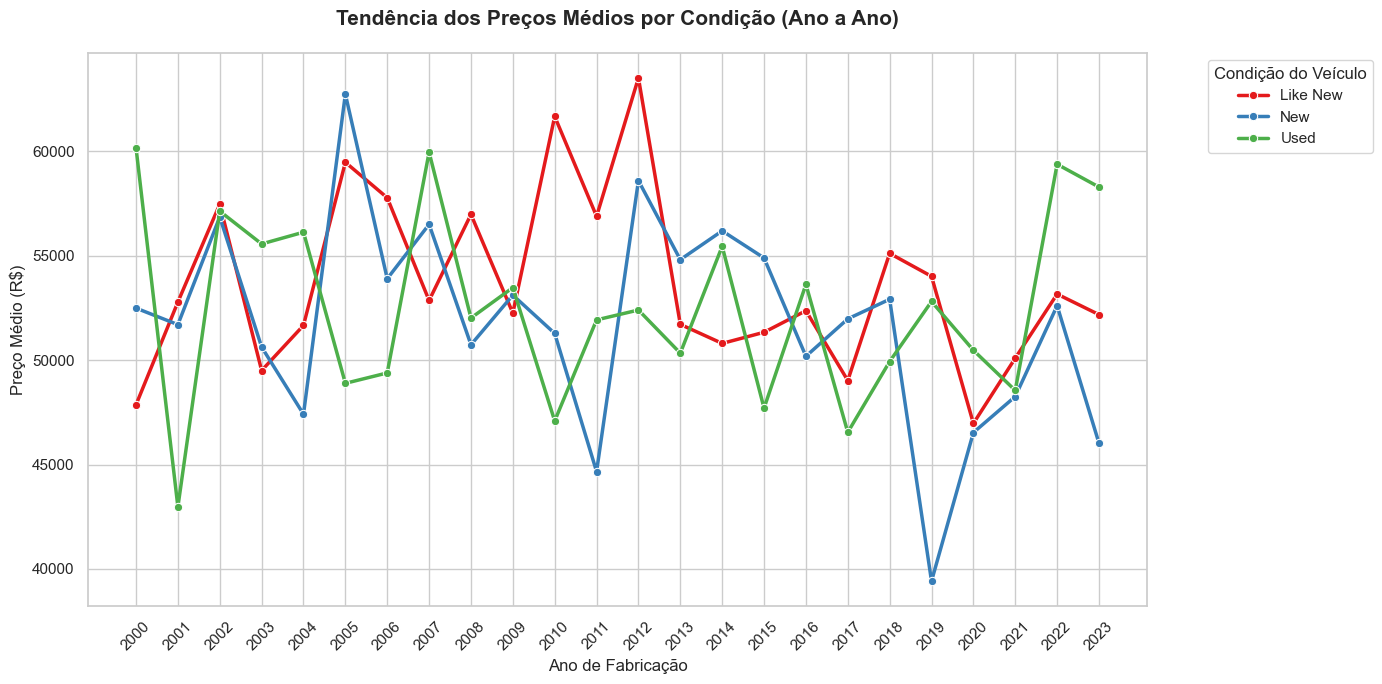

--- Variabilidade (Desvio Padrão) dos Preços Médios por Condição ---
Condition
Like New    4217.68
New         4947.00
Used        4584.96
Name: Price, dtype: float64


In [19]:
# Configuração de estilo
sns.set_theme(style="whitegrid")

print("\n" + "="*60)
print("EVOLUÇÃO TEMPORAL: PREÇO MÉDIO POR CONDIÇÃO AO LONGO DOS ANOS")
print("="*60)

# 1. Agrupamento para calcular a média de preço por Ano e por Condição
df_temp_cond = df.groupby(['Year', 'Condition'])['Price'].mean().reset_index()

# 2. Visualização com Gráfico de Linhas (Time Series)
plt.figure(figsize=(14, 7))

# Plotando as linhas para cada condição
sns.lineplot(
    data=df_temp_cond, 
    x='Year', 
    y='Price', 
    hue='Condition', 
    marker='o', 
    linewidth=2.5,
    palette='Set1'
)

# Estilização do gráfico
plt.title('Tendência dos Preços Médios por Condição (Ano a Ano)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Ano de Fabricação', fontsize=12)
plt.ylabel('Preço Médio (R$)', fontsize=12)
plt.legend(title='Condição do Veículo', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustando o eixo X para mostrar os anos de forma clara
anos_unicos = sorted(df['Year'].unique())
plt.xticks(anos_unicos, rotation=45)

plt.tight_layout()
plt.show()

# 3. Análise Numérica de Volatilidade
print("--- Variabilidade (Desvio Padrão) dos Preços Médios por Condição ---")
volatilidade = df_temp_cond.groupby('Condition')['Price'].std().round(2)
print(volatilidade)

TESTE DE HIPÓTESE: ANOVA (ONE-WAY)
Estatística F: 0.7431
P-Value: 4.7572e-01

Conclusão: FALHAMOS em rejeitar a Hipótese Nula (H0). Não há evidência estatística de diferença real; as variações podem ser obra do acaso.


C:\Users\gustavos\AppData\Local\Temp\ipykernel_11916\316065980.py:34: UserWarning:



The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.




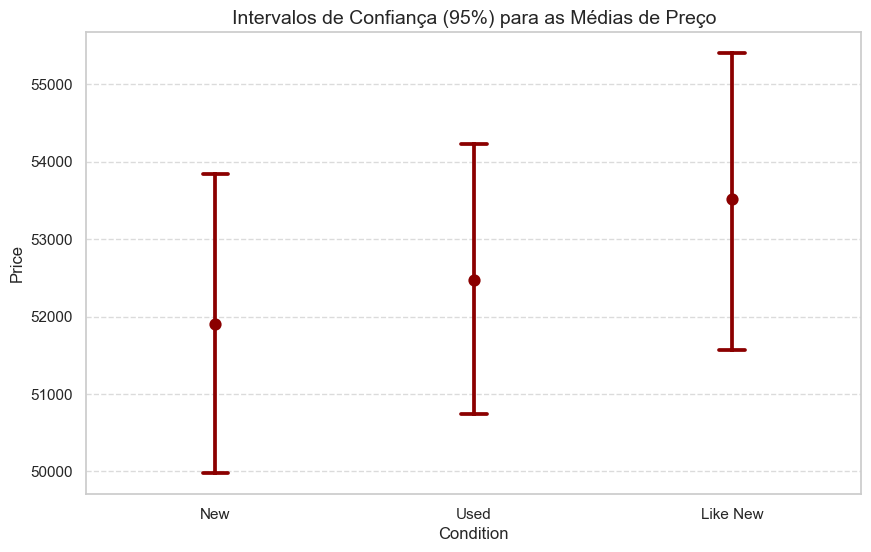

In [21]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("TESTE DE HIPÓTESE: ANOVA (ONE-WAY)")
print("="*60)

# 1. Definição das Hipóteses
# H0 (Hipótese Nula): As médias de preço para todas as condições são iguais.
# H1 (Hipótese Alternativa): Pelo menos uma condição tem média de preço diferente.

# 2. Preparação dos grupos
grupos = [df[df['Condition'] == c]['Price'] for c in df['Condition'].unique()]

# 3. Execução do Teste F de Snedecor (ANOVA)
f_stat, p_value = stats.f_oneway(*grupos)

print(f"Estatística F: {f_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

# 4. Interpretação dos resultados
alfa = 0.05
if p_value < alfa:
    resultado = "REJEITAMOS a Hipótese Nula (H0). As diferenças de preço são estatisticamente significativas."
else:
    resultado = "FALHAMOS em rejeitar a Hipótese Nula (H0). Não há evidência estatística de diferença real; as variações podem ser obra do acaso."

print(f"\nConclusão: {resultado}")

# 5. Visualização de Apoio: Pointplot (Foco na Média e Intervalo de Confiança)
plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='Condition', y='Price', join=False, capsize=.1, color='darkred')
plt.title('Intervalos de Confiança (95%) para as Médias de Preço', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

MODELO PREDITIVO: RANDOM FOREST REGRESSOR
Erro Médio Absoluto (MAE): R$ 24316.76
Coeficiente de Determinação (R²): -0.0552


C:\Users\gustavos\AppData\Local\Temp\ipykernel_11916\291231905.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




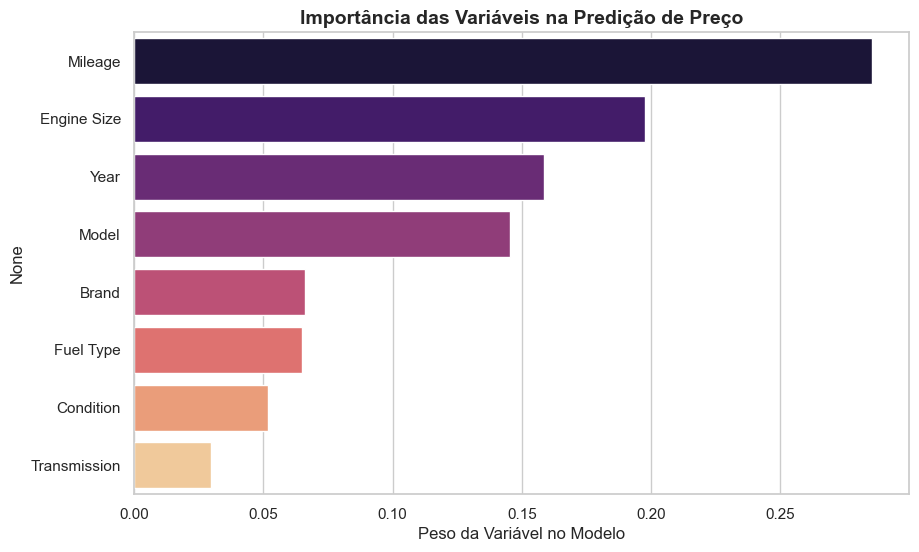

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. Preparação dos Dados (Feature Engineering)
# Criando uma cópia para não alterar o DF original das análises anteriores
df_ml = df.copy()

# Transformando variáveis categóricas (texto) em números
# Para um portfólio, o LabelEncoder é eficiente para variáveis ordinais ou muitas categorias
le = LabelEncoder()
categorical_cols = ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# 2. Definição de Variáveis Alvo (y) e Preditivas (X)
X = df_ml.drop(['Car ID', 'Price'], axis=1) # Removemos o ID pois não tem poder preditivo
y = df_ml['Price']

# 3. Divisão em Treino e Teste (80% para aprender, 20% para validar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("="*60)
print("MODELO PREDITIVO: RANDOM FOREST REGRESSOR")
print("="*60)

# 4. Treinamento do Modelo
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Predições e Avaliação
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Médio Absoluto (MAE): R$ {mae:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")

# 6. IMPORTÂNCIA DAS VARIÁVEIS (O que realmente define o preço?)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='magma')
plt.title('Importância das Variáveis na Predição de Preço', fontsize=14, fontweight='bold')
plt.xlabel('Peso da Variável no Modelo')
plt.show()

AVALIAÇÃO DO MODELO DE MACHINE LEARNING
R² Score (Poder de explicação): -0.0878
MAE (Erro Médio Absoluto): R$ 24625.53


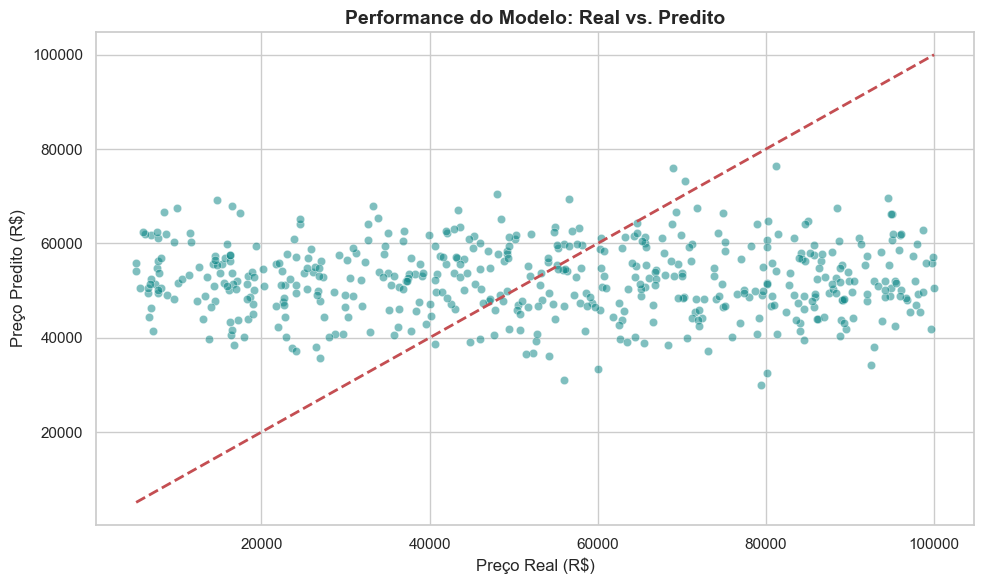

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Preparação dos dados
# Definindo features (X) e alvo (y)
# Removemos 'Car ID' e 'Model' (pela alta cardinalidade no portfólio inicial)
X = df.drop(columns=['Price', 'Car ID', 'Model'])
y = df['Price']

# 2. Pré-processamento: Tratando variáveis categóricas
categorical_features = ['Brand', 'Fuel Type', 'Transmission', 'Condition']
numeric_features = ['Year', 'Engine Size', 'Mileage']

# Criando o transformador para converter texto em números (OneHotEncoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# 3. Criando o Pipeline (Boas práticas de Engenharia de Dados)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 4. Divisão Treino e Teste (Rigor Estatístico)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Treinamento
model_pipeline.fit(X_train, y_train)

# 6. Predição e Avaliação
y_pred = model_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("="*60)
print("AVALIAÇÃO DO MODELO DE MACHINE LEARNING")
print("="*60)
print(f"R² Score (Poder de explicação): {r2:.4f}")
print(f"MAE (Erro Médio Absoluto): R$ {mae:.2f}")

# 7. Visualização: Valores Reais vs. Preditos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

plt.title('Performance do Modelo: Real vs. Predito', fontsize=14, fontweight='bold')
plt.xlabel('Preço Real (R$)', fontsize=12)
plt.ylabel('Preço Predito (R$)', fontsize=12)

# Removendo a legenda conforme solicitado
plt.legend([], frameon=False) 

plt.tight_layout()
plt.show()

R² (Coeficiente de Determinação): -0.0878
RMSE (Raiz do Erro Quadrático Médio): R$ 28706.32


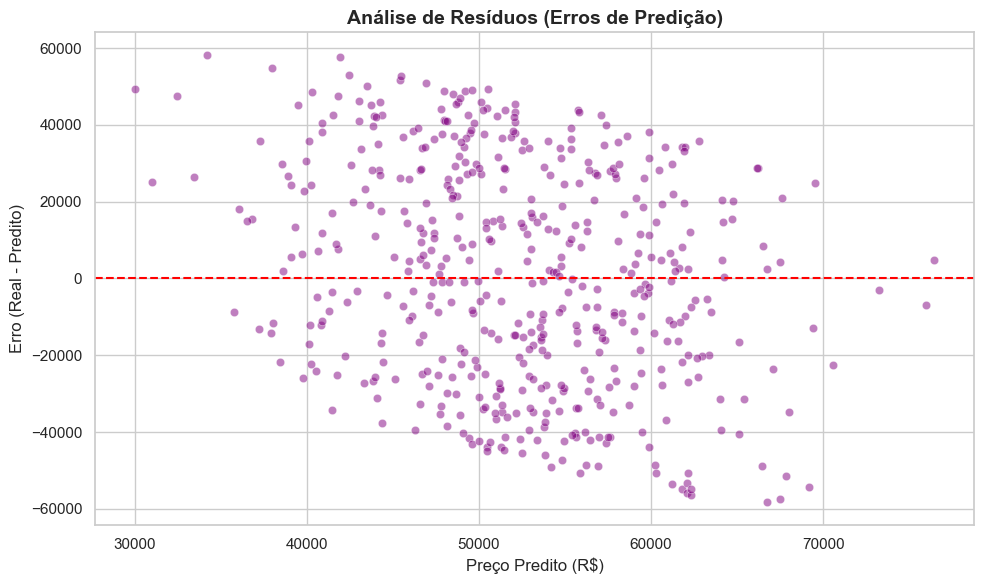

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

# Cálculo das métricas de erro
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): R$ {rmse:.2f}")

# Gráfico de Resíduos (Fundamental para validar se o modelo é tendencioso)
plt.figure(figsize=(10, 6))
residuos = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuos, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Análise de Resíduos (Erros de Predição)', fontsize=14, fontweight='bold')
plt.xlabel('Preço Predito (R$)', fontsize=12)
plt.ylabel('Erro (Real - Predito)', fontsize=12)

# Removendo qualquer legenda
plt.legend([], frameon=False) 

plt.tight_layout()
plt.show()